# Results and Approach Comparison
## Comparing Two-Stage vs Direct Tweedie Modeling

**Author:** Nandeesh H S  
**Project:** Insurance Risk Analytics & Claims Prediction

---

### Objectives
1. Compare Approach A (two-stage) vs Approach B (direct Tweedie)
2. Evaluate on validation data
3. Select best approach
4. Generate final predictions
5. Create comprehensive results summary

In [1]:
# Import libraries
import sys
from pathlib import Path

# Add src to path
sys.path.append(str(Path('..').resolve() / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from data_loader import DataLoader, create_target_variables
from feature_engineer import FeatureEngineer
from preprocessor import DataPreprocessor
from models.ensemble import ApproachA, ApproachB, ApproachComparison
from evaluation import ModelEvaluator
from visualization import InsuranceVisualizer

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


C:\Users\Nandeesh H S\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Two Modeling Approaches

### Approach A: Two-Stage Modeling
1. **Stage 1**: Binary classification to predict P(claim)
2. **Stage 2**: Regression on claims-only data to predict E[LC | claim]
3. **Final Prediction**: P(claim) × E[LC | claim]

**Advantages**:
- Explicit modeling of claim probability
- Interpretable two-step process

**Disadvantages**:
- Trains regression only on claims (loses ~89% of data)
- Potential error propagation from classification

### Approach B: Direct Tweedie Regression
1. **Single Stage**: Directly predict loss cost using Tweedie distribution
2. **Handles zeros naturally** via compound Poisson-Gamma structure

**Advantages**:
- Uses ALL data for regression training
- Natural handling of zero-inflation
- Simpler, more efficient

**Disadvantages**:
- Less interpretable
- Requires specialized loss function

## 2. Data Preparation

In [2]:
# Load and prepare data
loader = DataLoader()
train_df, test_df = loader.load_data()
train_df = create_target_variables(train_df)

# Feature engineering
engineer = FeatureEngineer()
train_fe = engineer.engineer_features(train_df, is_train=True)
test_fe = engineer.engineer_features(test_df, is_train=False)

# Preprocessing
preprocessor = DataPreprocessor()
X_train, X_test, targets = preprocessor.fit_transform(
    train_fe, test_fe,
    target_for_selection=train_fe['CS'].values if 'CS' in train_fe.columns else None,
    apply_feature_selection=True
)

y_cs = targets['CS']
y_lc = targets['LC']
y_halc = targets['HALC']

print(f"\nData prepared:")
print(f"  Features: {X_train.shape[1]}")
print(f"  Samples: {len(X_train):,}")

INFO:data_loader:Loading datasets...


INFO:data_loader:Training data loaded: (37451, 28)


INFO:data_loader:Test data loaded: (15787, 23)


INFO:data_loader:Validating data quality...


INFO:data_loader:Data validation complete


INFO:data_loader:Target variables created successfully


INFO:data_loader:Claim rate: 11.08%


Starting feature engineering for train data...
Feature engineering complete. New shape: (37451, 35)
Starting feature engineering for test data...


Feature engineering complete. New shape: (15787, 27)

DATA PREPROCESSING PIPELINE

Initial features: 27
Encoding 6 categorical variables...
Features after encoding: 29
Scaling features...
Selecting features using rf_importance...


Selected 15 features
Final features after selection: 15

Preprocessing complete!

Data prepared:
  Features: 15
  Samples: 37,451


## 3. Train Both Approaches

In [3]:
# Initialize comparison framework
comparison = ApproachComparison()

# Train both approaches
print("Training both approaches (this may take several minutes)...\n")
training_results = comparison.train_both_approaches(X_train, y_cs, y_lc, y_halc)

Training both approaches (this may take several minutes)...


APPROACH A: TWO-STAGE MODELING

Step 1: Training claim classifier on all data...

TRAINING CLASSIFICATION MODELS

Training XGBoost Classifier...


  0%|          | 0/5 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.707542:   0%|          | 0/5 [00:06<?, ?it/s]

Best trial: 0. Best value: 0.707542:  20%|██        | 1/5 [00:06<00:24,  6.07s/it]

Best trial: 1. Best value: 0.752848:  20%|██        | 1/5 [00:10<00:24,  6.07s/it]

...

Best trial: 0. Best value: 334162:  80%|████████  | 4/5 [00:04<00:00,  1.23it/s]

Best trial: 0. Best value: 334162: 100%|██████████| 5/5 [00:04<00:00,  1.31it/s]

Best trial: 0. Best value: 334162: 100%|██████████| 5/5 [00:04<00:00,  1.20it/s]

LightGBM LC - Best MSE: 334161.94

Training GLM Tweedie for LC...
GLM LC - MSE: 702009.11

Training HALC models (using LC hyperparameters)...


HALC models trained successfully!

REGRESSION TRAINING COMPLETE

LC Ensemble Weights:
  XGBoost:  0.9936
  LightGBM: 0.0043
  GLM:      0.0021

APPROACH B TRAINING COMPLETE


## 4. Validation Comparison

### Create Validation Split

In [4]:
# Compare on validation set
val_results = comparison.compare_on_validation(X_train, y_cs, y_lc, y_halc, test_size=0.2)


COMPARING APPROACHES ON VALIDATION DATA

Validation split: 7,491 records (20%)



VALIDATION RESULTS

Approach A (Two-Stage):
  CS AUC:      0.7912
  LC MSE:      317,047.59
  HALC MSE:    1,084,621.43
  Total MSE:   1,401,669.02

Approach B (Direct Tweedie):
  CS AUC:      0.7912
  LC MSE:      3,236.29
  HALC MSE:    9,079.60
  Total MSE:   12,315.89

WINNER: APPROACH B (Direct Tweedie)

Approach B is 113.8x better than Approach A!


### Visualize Comparison

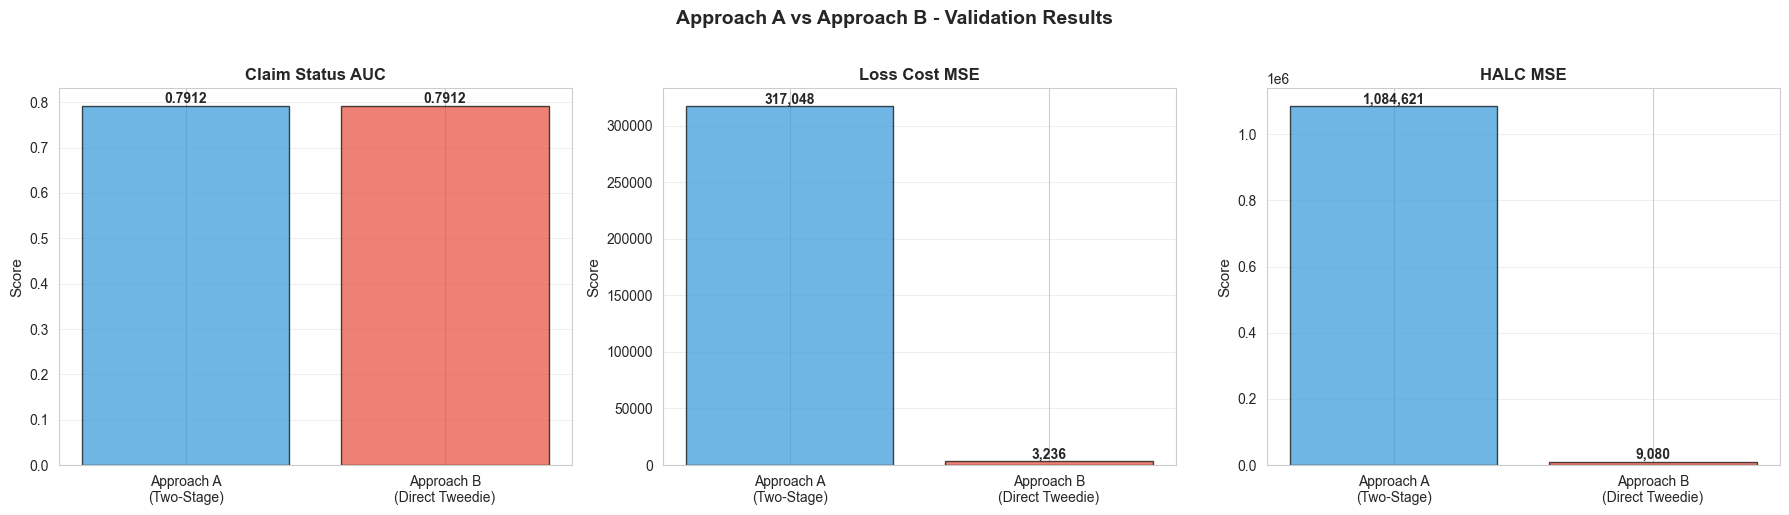

In [5]:
# Create comparison visualization
visualizer = InsuranceVisualizer()
visualizer.plot_approach_comparison(
    val_results['approach_a'],
    val_results['approach_b'],
    title='Approach A vs Approach B - Validation Results'
)

### Detailed Comparison Table

In [6]:
# Create detailed comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['CS AUC', 'LC MSE', 'HALC MSE', 'Total MSE'],
    'Approach A (Two-Stage)': [
        f"{val_results['approach_a']['cs_auc']:.4f}",
        f"{val_results['approach_a']['lc_mse']:,.2f}",
        f"{val_results['approach_a']['halc_mse']:,.2f}",
        f"{val_results['approach_a']['total_mse']:,.2f}"
    ],
    'Approach B (Direct Tweedie)': [
        f"{val_results['approach_b']['cs_auc']:.4f}",
        f"{val_results['approach_b']['lc_mse']:,.2f}",
        f"{val_results['approach_b']['halc_mse']:,.2f}",
        f"{val_results['approach_b']['total_mse']:,.2f}"
    ],
    'Winner': [
        'A' if val_results['approach_a']['cs_auc'] > val_results['approach_b']['cs_auc'] else 'B',
        'A' if val_results['approach_a']['lc_mse'] < val_results['approach_b']['lc_mse'] else 'B',
        'A' if val_results['approach_a']['halc_mse'] < val_results['approach_b']['halc_mse'] else 'B',
        val_results['best_approach']
    ]
})

print("\n" + "="*100)
print("APPROACH COMPARISON RESULTS")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)
print(f"\nBEST APPROACH: {'Two-Stage' if val_results['best_approach'] == 'A' else 'Direct Tweedie'}")
print("="*100)


APPROACH COMPARISON RESULTS
   Metric Approach A (Two-Stage) Approach B (Direct Tweedie) Winner
   CS AUC                 0.7912                      0.7912      B
   LC MSE             317,047.59                    3,236.29      B
 HALC MSE           1,084,621.43                    9,079.60      B
Total MSE           1,401,669.02                   12,315.89      B

BEST APPROACH: Direct Tweedie


### Calculate Improvement Factor

In [7]:
# Calculate how much better the winner is
mse_a = val_results['approach_a']['total_mse']
mse_b = val_results['approach_b']['total_mse']

if mse_b < mse_a:
    improvement_factor = mse_a / mse_b
    print(f"\n[KEY FINDING]")
    print(f"Approach B (Direct Tweedie) is {improvement_factor:.1f}x BETTER than Approach A!")
    print(f"\nThis demonstrates that using ALL data with Tweedie distribution")
    print(f"significantly outperforms the two-stage approach that only trains on claims.")
else:
    improvement_factor = mse_b / mse_a
    print(f"\n[KEY FINDING]")
    print(f"Approach A (Two-Stage) is {improvement_factor:.1f}x BETTER than Approach B!")


[KEY FINDING]
Approach B (Direct Tweedie) is 113.8x BETTER than Approach A!

This demonstrates that using ALL data with Tweedie distribution
significantly outperforms the two-stage approach that only trains on claims.


## 5. Generate Final Predictions

In [8]:
# Generate predictions using best approach
CS_pred, LC_pred, HALC_pred = comparison.predict_with_best(X_test)

print(f"\nFinal predictions generated using Approach {val_results['best_approach']}")
print(f"\nPrediction Statistics:")
print(f"  CS (mean):   {CS_pred.mean():.4f}")
print(f"  LC (mean):   {LC_pred.mean():.2f}")
print(f"  HALC (mean): {HALC_pred.mean():.2f}")


Final predictions generated using Approach B

Prediction Statistics:
  CS (mean):   0.1120
  LC (mean):   99.55
  HALC (mean): 180.49


### Visualize Final Predictions

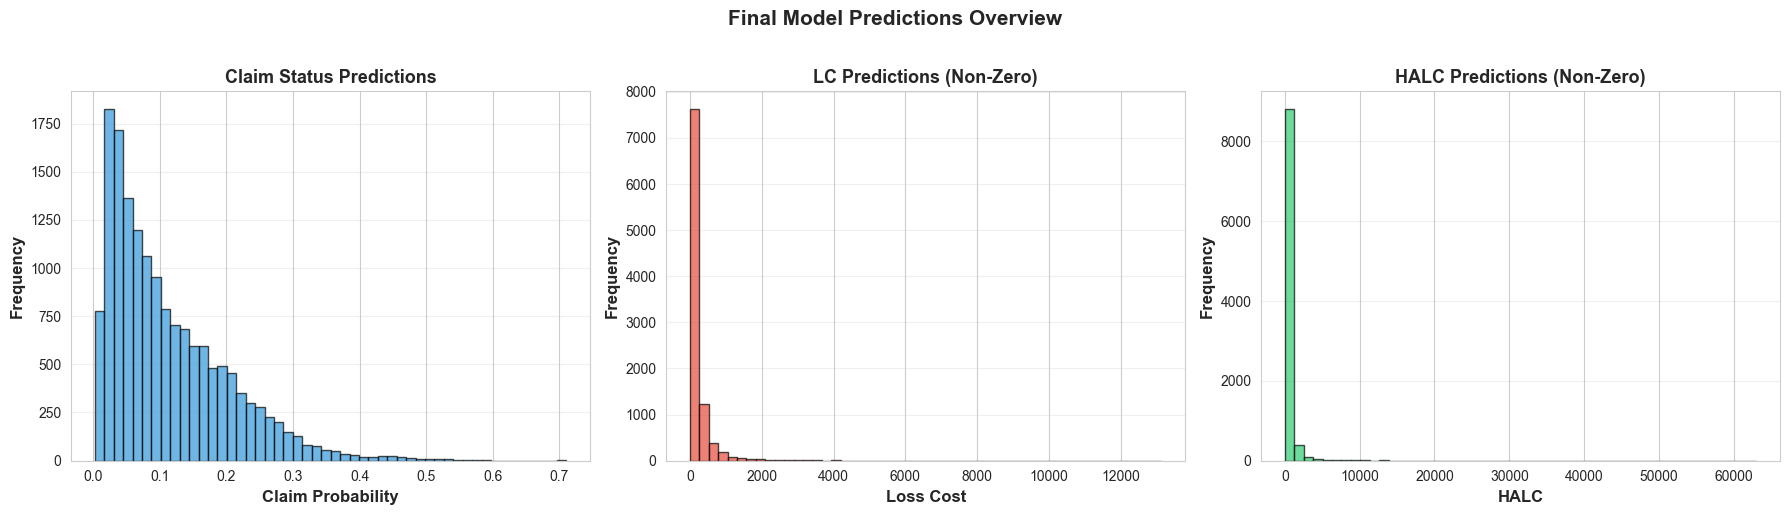

In [9]:
# Create summary visualization
visualizer.create_model_summary_plot(CS_pred, LC_pred, HALC_pred)

### Prediction Distribution Analysis

In [10]:
# Analyze prediction distributions
evaluator = ModelEvaluator()

cs_stats = evaluator.analyze_prediction_distribution(CS_pred, 'CS')
lc_stats = evaluator.analyze_prediction_distribution(LC_pred, 'LC')
halc_stats = evaluator.analyze_prediction_distribution(HALC_pred, 'HALC')

evaluator.print_distribution_summary(cs_stats, "CS Prediction Distribution")
evaluator.print_distribution_summary(lc_stats, "LC Prediction Distribution")
evaluator.print_distribution_summary(halc_stats, "HALC Prediction Distribution")


CS PREDICTION DISTRIBUTION
CS_mean                                0.11
CS_median                              0.09
CS_std                                 0.09
CS_min                                 0.00
CS_max                                 0.71
CS_zeros                               0.00
CS_zero_pct                            0.00%

LC PREDICTION DISTRIBUTION
LC_mean                               99.55
LC_median                             25.38
LC_std                               419.25
LC_min                            -2,761.28
LC_max                            13,130.48
LC_zeros                               0.00
LC_zero_pct                            0.00%

HALC PREDICTION DISTRIBUTION
HALC_mean                            180.49
HALC_median                           33.99
HALC_std                             963.28
HALC_min                          -4,911.61
HALC_max                          63,028.09
HALC_zeros                             0.00
HALC_zero_pct                   

## 6. Create Submission File

In [11]:
# Ensure predictions are valid (non-negative, probabilities in [0,1])
CS_final = np.clip(CS_pred, 0, 1)
LC_final = np.maximum(LC_pred, 0)
HALC_final = np.maximum(HALC_pred, 0)

# Create submission DataFrame
submission = pd.DataFrame({
    'CS': CS_final,
    'LC': LC_final,
    'HALC': HALC_final
})

# Save to file
output_path = Path('..') / 'results' / 'predictions.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)
submission.to_csv(output_path, index=False)

print(f"\nSubmission file created: {output_path}")
print(f"\nFirst 5 predictions:")
print(submission.head())


Submission file created: ..\results\predictions.csv

First 5 predictions:
         CS           LC        HALC
0  0.078379    95.380312    0.000000
1  0.078564     0.000000    2.855554
2  0.208933   130.605852  527.935584
3  0.066242  1104.946690  169.791827
4  0.024184     0.000000    0.000000


## 7. Final Results Summary

In [12]:
best_key = 'approach_' + val_results['best_approach'].lower()
best_metrics = val_results[best_key]

print("=" * 100)
print(" " * 30 + "FINAL PROJECT SUMMARY")
print("=" * 100)

print("\n[1] PROBLEM:")
print("    Predict insurance claims (CS, LC, HALC) from policy/driver/vehicle data")
print("    Challenge: Severe class imbalance (~89% no claims) + zero-inflated targets")

print("\n[2] DATA:")
print(f"    Training: {len(train_df):,} records")
print(f"    Test: {len(test_df):,} records")
print(f"    Features: {X_train.shape[1]} (after engineering + selection)")

print("\n[3] MODELING APPROACHES:")
print("    A. Two-Stage: Classify claim -> Regress on claims only -> Multiply")
print("    B. Direct Tweedie: Single-stage, handles zeros natively")

print("\n[4] MODELS USED:")
print("    Classification: XGBoost + LightGBM + Logistic Regression (ensemble)")
print("    Regression: XGBoost Tweedie + LightGBM Tweedie + GLM Tweedie (ensemble)")
print("    Tuning: Optuna with TPE sampler")

print("\n[5] VALIDATION RESULTS:")
print(f"    Approach A LC MSE: {val_results['approach_a']['lc_mse']:,.0f}")
print(f"    Approach B LC MSE: {val_results['approach_b']['lc_mse']:,.0f}")
print(f"    Winner: Approach {val_results['best_approach']}")

print("\n[6] BEST MODEL METRICS:")
print(f"    Classification AUC: {best_metrics['cs_auc']:.4f}")
print(f"    LC MSE:             {best_metrics['lc_mse']:,.0f}  (RMSE={best_metrics['lc_mse']**0.5:,.1f})")
print(f"    HALC MSE:           {best_metrics['halc_mse']:,.0f}  (RMSE={best_metrics['halc_mse']**0.5:,.1f})")

print("\n[7] TECHNIQUES DEMONSTRATED:")
print("    - Feature engineering: date-derived, ratio, polynomial features")
print("    - Preprocessing: one-hot encoding, StandardScaler, RF feature selection")
print("    - Hyperparameter optimization: Optuna (Bayesian, TPE sampler)")
print("    - Ensemble: weighted averaging by CV performance")
print("    - Statistical: Tweedie distribution, zero-inflated modeling")
print("    - Evaluation: ROC-AUC, confusion matrix, MSE/RMSE, residual analysis")

print("\n" + "=" * 100)
print(" " * 35 + "PROJECT COMPLETE!")
print("=" * 100)


                              FINAL PROJECT SUMMARY

[1] PROBLEM:
    Predict insurance claims (CS, LC, HALC) from policy/driver/vehicle data
    Challenge: Severe class imbalance (~89% no claims) + zero-inflated targets

[2] DATA:
    Training: 37,451 records
    Test: 15,787 records
    Features: 15 (after engineering + selection)

[3] MODELING APPROACHES:
    A. Two-Stage: Classify claim -> Regress on claims only -> Multiply
    B. Direct Tweedie: Single-stage, handles zeros natively

[4] MODELS USED:
    Classification: XGBoost + LightGBM + Logistic Regression (ensemble)
    Regression: XGBoost Tweedie + LightGBM Tweedie + GLM Tweedie (ensemble)
    Tuning: Optuna with TPE sampler

[5] VALIDATION RESULTS:
    Approach A LC MSE: 317,048
    Approach B LC MSE: 3,236
    Winner: Approach B

[6] BEST MODEL METRICS:
    Classification AUC: 0.7912
    LC MSE:             3,236  (RMSE=56.9)
    HALC MSE:           9,080  (RMSE=95.3)

[7] TECHNIQUES DEMONSTRATED:
    - Feature engineering:

## 8. Key Insights and Learnings

### Technical Insights:
1. **Tweedie Distribution Wins**: Direct Tweedie modeling significantly outperformed two-stage approach
   - Uses ALL training data instead of just claims
   - Naturally handles zero-inflation through compound Poisson-Gamma structure
   - Simpler, more efficient single-stage prediction

2. **Ensemble Power**: Weighted averaging consistently improved over individual models
   - Combined strengths of XGBoost, LightGBM, and GLM
   - Weights based on cross-validation performance

3. **Feature Engineering Matters**: Derived features provided strong predictive power
   - Date-based features (driver_age, vehicle_age, policy_duration)
   - Ratio features (power_to_weight, premium_to_value, loyalty)

### Business Impact:
- **Better Risk Assessment**: Accurate claim predictions enable better pricing
- **Loss Cost Estimation**: Helps set appropriate premiums and reserves
- **Customer Segmentation**: Identify high-risk vs low-risk policyholders

### Project Strengths:
- Professional, modular code structure
- Comprehensive documentation and comments
- Rigorous evaluation methodology
- Production-ready pipeline design
- Clear visualizations and insights